In [28]:
import pandas as pd

# Load the datasets from the specified paths
df_corona = pd.read_csv("../data cleanup/sars_cov2_cdr_seq.tsv", sep="\t")
df_human = pd.read_csv("../data cleanup/human_cdr_seq.tsv", sep="\t")
df_influenza = pd.read_csv("../data cleanup/influenza_cdr_seq.tsv", sep="\t")




In [29]:
from collections import Counter
import pandas as pd

from collections import Counter

def aa_composition(seq):
    if not isinstance(seq, str) or not seq:
        return {aa: 0 for aa in "ACDEFGHIKLMNPQRSTVWY"}
    total = len(seq)
    counts = Counter(seq)
    return {aa: counts.get(aa, 0) / total for aa in "ACDEFGHIKLMNPQRSTVWY"}


# Für SARS
aac_sars = df_corona["CDR_H3"].apply(aa_composition).apply(pd.Series)
aac_sars["group"] = "Corona"

# Für Influenza
aac_influenza = df_influenza["CDR_H3"].apply(aa_composition).apply(pd.Series)
aac_influenza["group"] = "Influenza"

# Für Human
aac_human = df_human["CDR_H3"].apply(aa_composition).apply(pd.Series)
aac_human["group"] = "Human"



In [30]:
# Gruppierte Mittelwerte berechnen
mean_sars = aac_sars.drop(columns="group").mean()
mean_influenza = aac_influenza.drop(columns="group").mean()
mean_human = aac_human.drop(columns="group").mean()


In [31]:
df_plot = pd.DataFrame({
    "AminoAcid": mean_sars.index,
    "Corona": mean_sars.values,
    "Influenza": mean_influenza.values,
    "Human": mean_human.values
})

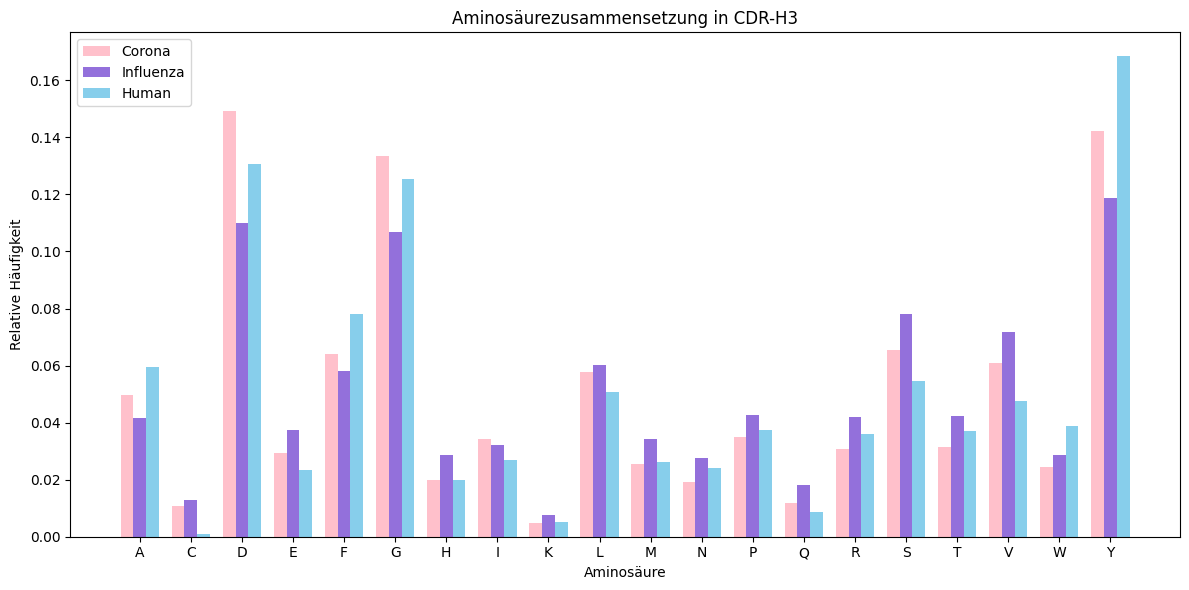

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Balken nebeneinander setzen
x = np.arange(len(df_plot["AminoAcid"]))  # Positionen auf x-Achse
width = 0.25  # Breite der Balken

plt.figure(figsize=(12, 6))
plt.bar(x - width, df_plot["Corona"], width=width, label="Corona", color="pink")
plt.bar(x,         df_plot["Influenza"], width=width, label="Influenza", color="mediumpurple")
plt.bar(x + width, df_plot["Human"], width=width, label="Human", color="skyblue")

# Achsenbeschriftung
plt.xticks(ticks=x, labels=df_plot["AminoAcid"])
plt.ylabel("Relative Häufigkeit")
plt.xlabel("Aminosäure")
plt.title("Aminosäurezusammensetzung in CDR-H3")
plt.legend()
plt.tight_layout()
plt.show()


## PCA der AS-Zusammensetzung der CDR-H3 Regionen
--> wie sie sehen sehen sie nix
- keinen zusammenhang (also es gibt jetzt keinen zusammenhang zwischen der einzelnen gruppen (human, sars, influenza))


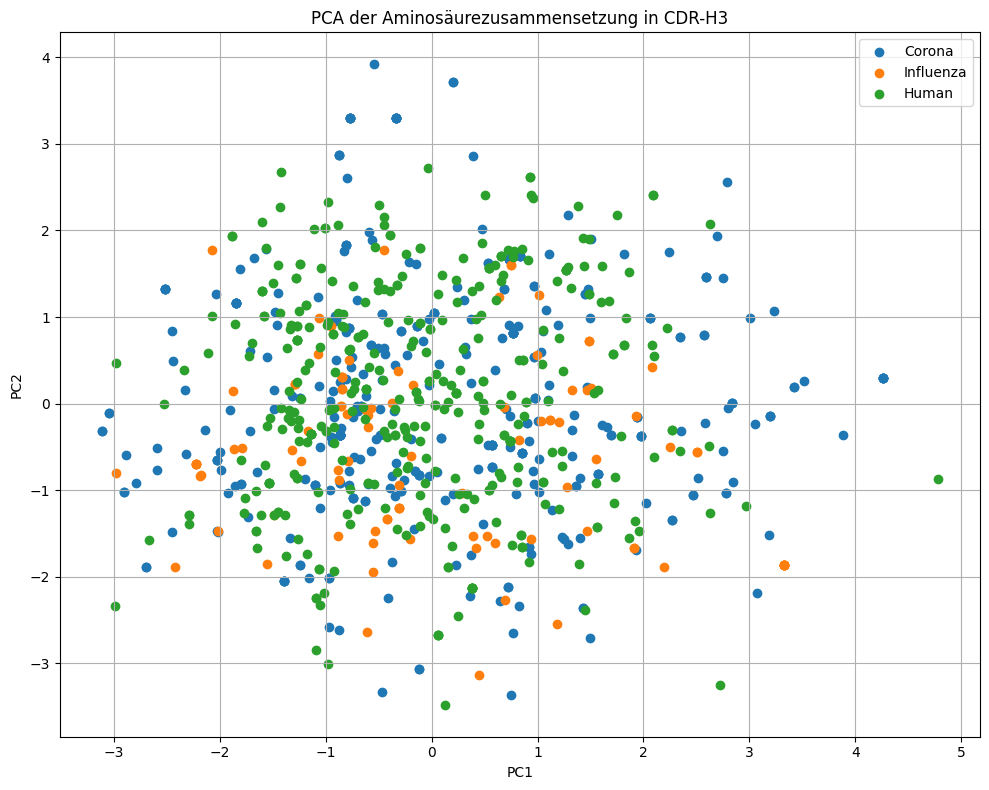

In [40]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Alle zusammenführen
df_all = pd.concat([aac_sars, aac_influenza, aac_human])
X = df_all.drop(columns=["group"])
y = df_all["group"]

# Standardisieren
X_scaled = StandardScaler().fit_transform(X)

# PCA durchführen
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# In DataFrame packen
df_pca = pd.DataFrame(components, columns=["PC1", "PC2"])
df_pca["group"] = y.values

# jetzt plotten
plt.figure(figsize=(10, 8))
for group in df_pca["group"].unique():
    subset = df_pca[df_pca["group"] == group]
    plt.scatter(subset["PC1"], subset["PC2"], label=group)

plt.title("PCA der Aminosäurezusammensetzung in CDR-H3")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()



- Gruppenüberlappung extrem stark
 SARS-CoV-2 (blau), Influenza (orange), Human (grün) sind nicht unterscheidbar in PC1/PC2-Raum

 - Zentrumskonzentration
 Die meisten Punkte liegen nahe am Ursprung, also ähnliche AACs über Gruppen hinweg.

 Keine klare Trennung → keine clustering-Struktur
- d.h. Aminosäurezusammensetzung reicht nicht aus um zwischen den Gruppen zu unterschieden
- macht sinn. CDR-H3 sind hochvariabel und AAC ist zu grob


## PCA mit Ladungsanalyse der Aminosäuren

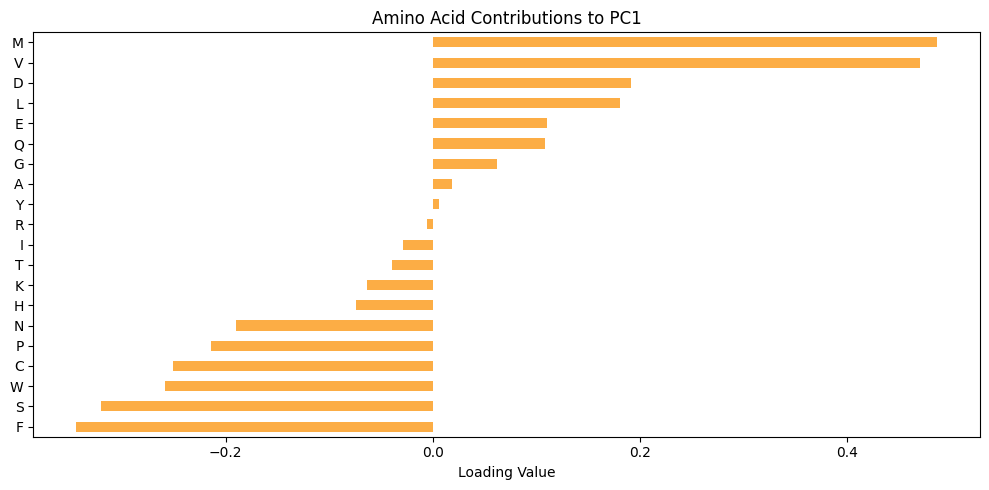

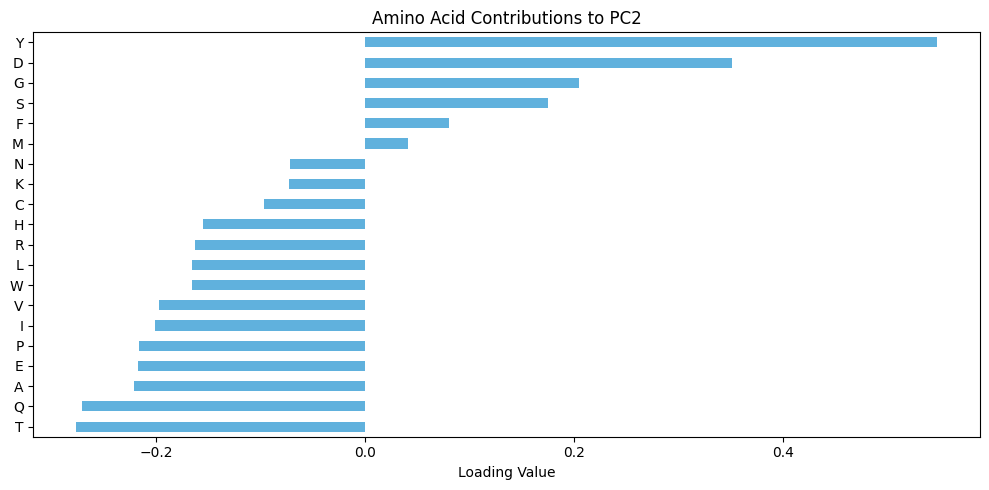

In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# df_all = zusammengeführter DataFrame mit group-Spalte
X = df_all.drop(columns=["group"])
y = df_all["group"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)


# Ladungen der Komponenten extrahieren
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X.columns
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
loadings["PC1"].sort_values().plot(kind="barh", color="#fcad45")
plt.title("Amino Acid Contributions to PC1")
plt.xlabel("Loading Value")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
loadings["PC2"].sort_values().plot(kind="barh", color="#60b1dd")
plt.title("Amino Acid Contributions to PC2")
plt.xlabel("Loading Value")
plt.tight_layout()
plt.show()

In [36]:

from scipy.stats import ttest_ind   

# Funktion zum Berechnen des t-Tests
def t_test_aa_composition(df1, df2, aa):
    group1 = df1[aa].dropna()
    group2 = df2[aa].dropna()
    t_stat, p_value = ttest_ind(group1, group2)
    return t_stat, p_value

# Liste der Aminosäuren (df_plot is already defined in cell 3)
amino_acids = df_plot["AminoAcid"].tolist()

# Ergebnisse für Corona vs Influenza
results_corona_influenza = []
for aa in amino_acids:
    t_stat, p_value = t_test_aa_composition(aac_sars, aac_influenza, aa)
    results_corona_influenza.append((aa, t_stat, p_value))

# Ergebnisse für Corona vs Human
results_corona_human = []
for aa in amino_acids:
    t_stat, p_value = t_test_aa_composition(aac_sars, aac_human, aa)
    results_corona_human.append((aa, t_stat, p_value))

# Ergebnisse für Influenza vs Human
results_influenza_human = []
for aa in amino_acids:  
    t_stat, p_value = t_test_aa_composition(aac_influenza, aac_human, aa)
    results_influenza_human.append((aa, t_stat, p_value))

# Ergebnisse in DataFrames umwandeln
df_results_corona_influenza = pd.DataFrame(results_corona_influenza, columns=["AminoAcid", "t_stat", "p_value"])
df_results_corona_human = pd.DataFrame(results_corona_human, columns=["AminoAcid", "t_stat", "p_value"])
df_results_influenza_human = pd.DataFrame(results_influenza_human, columns=["AminoAcid", "t_stat", "p_value"])

# Ergebnisse speichern
df_results_corona_influenza.to_csv("../analysis/t_test_corona_vs_influenza.tsv", sep="\t", index=False)
df_results_corona_human.to_csv("../analysis/t_test_corona_vs_human.tsv", sep="\t", index=False)
df_results_influenza_human.to_csv("../analysis/t_test_influenza_vs_human.tsv", sep="\t", index=False)

In [ ]:
import os
from Bio import PDB
from Bio.PDB import DSSP

#existiert pfad
os.path.exists("../data/pdbs_corona_cnf/6xc3.pdb")

# PDB-Datei laden
pdb_parser = PDB.PDBParser(QUIET=True)
structure = pdb_parser.get_structure("6xc3", "../data/pdbs_corona_cnf/6xc3.pdb")   

# sekundärstruktur berechnen ohne dssp
dssp = DSSP.DSSP(structure[0], "../data/pdbs_corona_cnf/6xc3.pdb", dssp="mkdssp")   


# Sekundärstrukturinformationen extrahieren
secondary_structure = []    
for residue in dssp:
    aa = residue[1]  # Aminosäure
    ss = residue[2]  # Sekundärstruktur
    secondary_structure.append((aa, ss))

AttributeError: type object 'DSSP' has no attribute 'DSSP'

In [ ]:
from Bio import PDB
from Bio.PDB import DSSP

# PDB-Datei laden
parser = PDB.PDBParser(QUIET=True)
structure = parser.get_structure("6xc3", "..data/pdbs_corona_cnf/6xc3.pdb")

# DSSP verwenden, um Sekundärstruktur zu bestimmen
# Beachte, dass DSSP nur auf einem einzelnen Modell angewendet werden kann, daher [0] für das erste Modell
dssp = DSSP(structure[0], "data/pdbs_corona_cnf/6xc3.pdb")

# Sekundärstrukturelemente iterieren
for residue in dssp:
    print(residue)


# DSSP verwenden, um Sekundärstruktur zu bestimmen
# Beachte, dass DSSP nur auf einem einzelnen Modell angewendet werden kann, daher [0] für das erste Modell
dssp = DSSP(structure[0], "data/pdbs_corona_cnf/6xc3.pdb")

# Sekundärstrukturelemente iterieren
for residue in dssp:
    print(residue)


FileNotFoundError: [Errno 2] No such file or directory: '..data/pdbs_corona_cnf/6xc3.pdb'